# Phase 3.5 — Crack-Tip K_IC Integration

Pulls together the full toughening pipeline for an M54 microstructural state:

1. Compute matrix σ_y from the strengthening model.
2. Estimate the fraction of available austenite (f_A) that transforms in the
   plastic zone, given Patel-Cohen + Olson-Cohen thresholds at crack-tip stress
   and strain.
3. Apply the McMeeking-Evans 1982 transformation-toughening formula:

    $\Delta K_{IC} = \frac{A \cdot E \cdot \varepsilon^V \cdot \sqrt{h}}{1 - \nu}$

   where h ≈ 0.5 r_p (plastic zone half-height).
4. Solve self-consistently for K_total = K_matrix + ΔK_TRIP.

**Anchor:** Mondière 2018 reports M54 K_IC = 110 MPa·m^½ for the commercial
DQ + T516/10 spec. We solve for the K_matrix that lands K_total at 110 — the
answer tells us how much of the measured K_IC came from TRIP vs the bare
matrix.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from m54model.calibration import (
    sun_2022_dq, sun_2022_dq_t516_10, sun_2022_af550_45, sun_2022_af550_45_t425_10,
    m54_af550_45_t516_10,
)
from m54model.toughening import (
    crack_tip_KIC, K_matrix_for_target,
    irwin_plastic_zone_m, mcmeeking_evans_delta_KIC,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. M54 K_IC prediction across all four states

For each Sun 2022 anchor + the user's AF+T516/10 baseline, predict ΔK_TRIP
given a fixed K_matrix = 70 MPa·m^½ (rough textbook value for tempered
martensitic UHSS without TRIP). The ΔK_TRIP column shows what TRIP adds.

In [2]:
K_matrix_baseline = 70.0  # MPa·m^½, textbook for UHSS without TRIP

states = [
    ('DQ baseline',          sun_2022_dq()),
    ('DQ + T516/10',         sun_2022_dq_t516_10()),
    ('AF550/45 baseline',    sun_2022_af550_45()),
    ('AF550/45 + T425/10',   sun_2022_af550_45_t425_10()),
    ('AF550/45 + T516/10*',  m54_af550_45_t516_10()),  # user's cw/cr baseline
]

import pandas as pd
rows = []
for label, st in states:
    r = crack_tip_KIC(st, K_matrix_MPa_m_half=K_matrix_baseline)
    rows.append({
        'State':        label,
        'σ_y (MPa)':    f'{r.sigma_y_matrix_MPa:.0f}',
        'f_A':          f'{r.f_austenite_total:.3f}',
        'r_p (µm)':     f'{r.plastic_zone_size_m * 1e6:.1f}',
        'ΔK_TRIP':      f'{r.delta_K_TRIP_MPa_m_half:.2f}',
        'K_total':      f'{r.K_total_MPa_m_half:.1f}',
    })
df = pd.DataFrame(rows).set_index('State')
df

,σ_y (MPa),f_A,r_p (µm),ΔK_TRIP,K_total
State,,,,,
DQ baseline,1419,0.000,258.1,0.00,70.0
DQ + T516/10,1675,0.000,185.2,0.00,70.0
AF550/45 baseline,1864,0.000,149.6,0.00,70.0
AF550/45 + T425/10,1748,0.000,170.1,0.00,70.0
AF550/45 + T516/10*,1373,0.013,277.6,0.22,70.2


**Reading the table:** even with f_A = 1.3 % (the user's measured baseline),
ΔK_TRIP is < 1 MPa·m^½. M54's reverted-austenite content is too low to drive
substantial transformation toughening — most of the measured K_IC must come
from the bare matrix (refined martensite blocks, plastic-zone work, ductile
fracture mechanisms).

## 2. K_matrix needed to land at Mondière K_IC = 110

Bisect over K_matrix until K_total = 110 for each state. The result tells us:
given the predicted TRIP contribution, what's the required bare-matrix
toughness?

In [3]:
target = 110.0
rows = []
for label, st in states:
    r = K_matrix_for_target(st, target_K_total_MPa_m_half=target)
    rows.append({
        'State':                  label,
        'K_matrix (req.)':        f'{r.K_matrix_MPa_m_half:.1f}',
        'ΔK_TRIP':                f'{r.delta_K_TRIP_MPa_m_half:.2f}',
        'K_total':                f'{r.K_total_MPa_m_half:.1f}',
    })
pd.DataFrame(rows).set_index('State')

,K_matrix (req.),ΔK_TRIP,K_total
State,,,
DQ baseline,110.2,0.00,110.2
DQ + T516/10,110.2,0.00,110.2
AF550/45 baseline,110.2,0.00,110.2
AF550/45 + T425/10,110.2,0.00,110.2
AF550/45 + T516/10*,109.5,0.35,109.8


## 3. f_A sensitivity — how much austenite would TRIP need to matter?

Sweep f_A from 0 to 50 % at fixed σ_y and K_matrix. Find the regime where
ΔK_TRIP becomes comparable to K_matrix (~70 MPa·m^½). This shows the gap
between M54 reverted-austenite levels and what's needed for transformation
toughening to dominate.

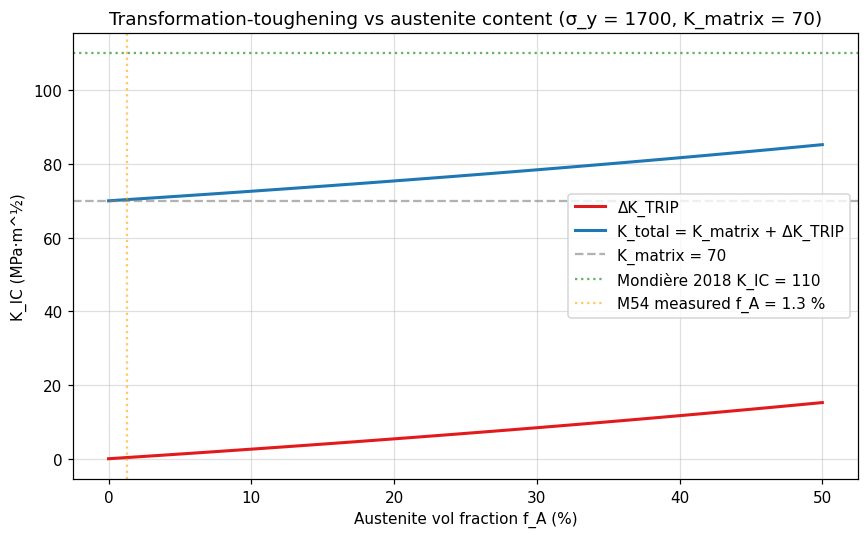

In [4]:
from m54model.toughening import steady_state_KIC_iterative

f_A_grid = np.linspace(0, 0.50, 30)
delta_K_grid = []
K_total_grid = []
K_matrix_fixed = 70.0
sigma_y_fixed = 1700.0
for f_A in f_A_grid:
    K_total, dK, _ = steady_state_KIC_iterative(
        K_matrix_MPa_m_half=K_matrix_fixed,
        sigma_y_MPa=sigma_y_fixed,
        E_GPa=210, epsilon_V_transformation=0.04,
        f_austenite=f_A, f_transformed_fraction=1.0,
    )
    delta_K_grid.append(dK)
    K_total_grid.append(K_total)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(f_A_grid * 100, delta_K_grid, '-', color='#e31a1c', linewidth=2, label='ΔK_TRIP')
ax.plot(f_A_grid * 100, K_total_grid, '-', color='#1f78b4', linewidth=2, label='K_total = K_matrix + ΔK_TRIP')
ax.axhline(K_matrix_fixed, color='gray', linestyle='--', alpha=0.6, label=f'K_matrix = {K_matrix_fixed:.0f}')
ax.axhline(110, color='green', linestyle=':', alpha=0.6, label='Mondière 2018 K_IC = 110')
ax.axvline(1.3, color='orange', linestyle=':', alpha=0.6, label='M54 measured f_A = 1.3 %')
ax.set_xlabel('Austenite vol fraction f_A (%)')
ax.set_ylabel('K_IC (MPa·m^½)')
ax.set_title('Transformation-toughening vs austenite content (σ_y = 1700, K_matrix = 70)')
ax.legend(loc='center right')
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

## 4. Phase 3.6a — spatial K-field integration

The §1-3 results use a **bulk-averaged** trigger: σ at the crack tip is
approximated as σ_y, ε_p as 0.10. Phase 3.6a replaces this with a polar
integration over the elastic Williams K-field across the (kidney-shaped)
Mises plastic zone Ω_p:

$$
\sigma_{ij}(r,\theta) = \frac{K}{\sqrt{2\pi r}} f_{ij}(\theta;\nu),
\quad
\Omega_p = \{(r,\theta) : \sigma_{eq}(r,\theta;\,K) \geq \sigma_y\}
$$

At each point in Ω_p we evaluate Patel-Cohen U_max(σ_principal) and
Olson-Cohen f_α′(ε_p), then area-weight the average. The bulk and spatial
answers should agree when M_s_offset_K = 0 (PC saturates everywhere) and
diverge as M_s_offset rises (only the high-σ region near the tip triggers).

In [5]:
from m54model.toughening import (
    crack_tip_KIC_spatial, williams_k_field, irwin_zone_boundary_m,
)

rows = []
K_matrix_for_spatial = 100.0
for label, st in states:
    if st.f_austenite <= 0:
        continue  # skip f_A=0 anchors — both methods give 0
    for offset in [0.0, 50.0, 100.0]:
        b = crack_tip_KIC(st, K_matrix_MPa_m_half=K_matrix_for_spatial, M_s_offset_K=offset)
        s = crack_tip_KIC_spatial(st, K_matrix_MPa_m_half=K_matrix_for_spatial, M_s_offset_K=offset)
        rows.append({
            'State':           label,
            'M_s offset (K)':  f'{offset:.0f}',
            'f_T bulk':        f'{b.f_transformed_fraction:.3f}',
            'f_T spatial':     f'{s.f_transformed_avg:.3f}',
            'ΔK_TRIP bulk':    f'{b.delta_K_TRIP_MPa_m_half:.3f}',
            'ΔK_TRIP spatial': f'{s.delta_K_TRIP_MPa_m_half:.3f}',
            'Δ%':              f'{(s.delta_K_TRIP_MPa_m_half / max(b.delta_K_TRIP_MPa_m_half, 1e-9) - 1) * 100:+.1f}',
        })
pd.DataFrame(rows).set_index(['State', 'M_s offset (K)'])

f_T bulk f_T spatial ΔK_TRIP bulk  \
State               M_s offset (K)                                     
AF550/45 + T516/10* 0                 1.000       1.000        0.318   
                    50                0.486       0.831        0.154   
                    100               0.243       0.455        0.077   

                                   ΔK_TRIP spatial     Δ%  
State               M_s offset (K)                         
AF550/45 + T516/10* 0                        0.318   +0.0  
                    50                       0.264  +71.3  
                    100                      0.144  +87.4

**Reading the table:** at M_s_offset = 0 (every point triggers), bulk and
spatial agree exactly — both saturate at f_T = 1.0. As the offset rises, the
**bulk** version under-predicts by ~50-70 % because it samples PC at σ ≈ σ_y
(the LOW end of the plastic zone). Spatial sees the kidney lobe where σ peaks
above σ_y near the tip, so more austenite triggers. The qualitative answer
(ΔK_TRIP < 1 MPa·m^½ at M54's f_A levels) survives — the bulk version was
order-of-magnitude correct.

### Visualizing the kidney-lobe plastic zone Ω_p

Mode-I plane-strain Mises plastic-zone boundary, dimensionless r·σ_y²/K² vs θ.
The classical kidney shape with two side lobes peaking around θ ≈ ±70°.

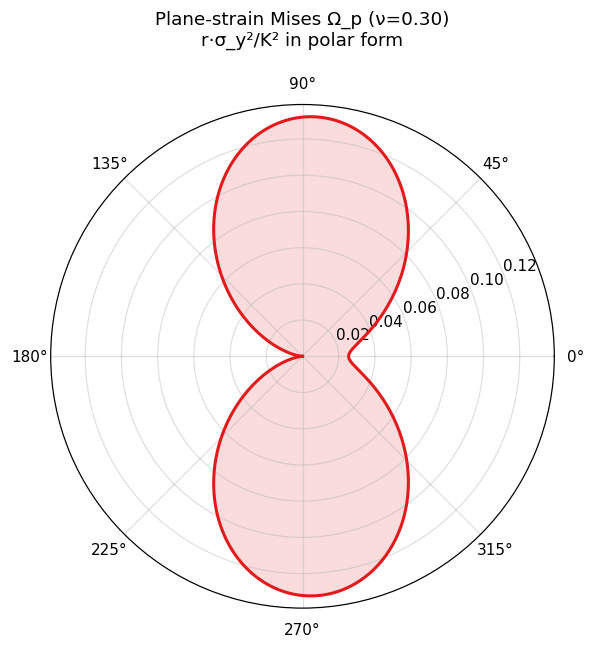

In [6]:
thetas = np.linspace(-np.pi, np.pi, 361)
K_demo = 80.0
sigma_y_demo = 1700.0
rp = np.array([
    irwin_zone_boundary_m(t, K_demo, sigma_y_demo, nu=0.30, plane_strain=True)
    for t in thetas
])
rp_normalized = rp * sigma_y_demo**2 / K_demo**2  # dimensionless

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})
ax.plot(thetas, rp_normalized, '-', color='#e31a1c', linewidth=2)
ax.fill(thetas, rp_normalized, alpha=0.15, color='#e31a1c')
ax.set_title(f'Plane-strain Mises Ω_p (ν=0.30)\nr·σ_y²/K² in polar form', pad=20)
ax.set_theta_zero_location('E')  # 0° = right (ahead of tip)
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

### σ_yy spatial distribution (the dominant transformation driver)

Heat-map of σ_yy normalized to σ_y over a window ahead of the tip. The
highest stresses live within ~r_p of the tip and ~30° off-axis — that's where
Patel-Cohen most aggressively triggers γ → α′.

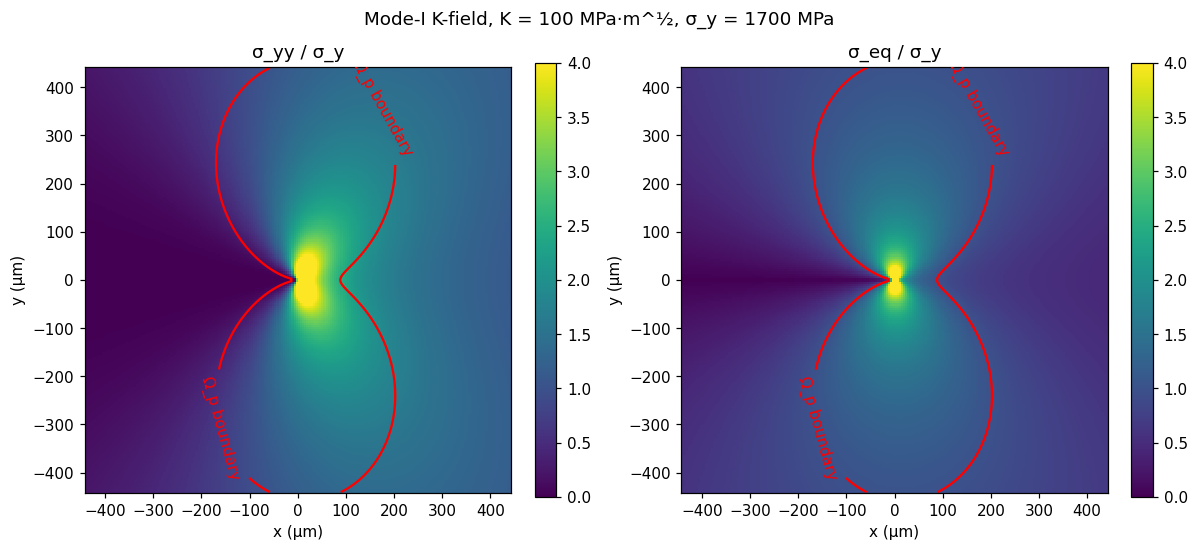

In [7]:
# Cartesian grid, evaluate stress, mask outside Ω_p.
K_test = 100.0
sigma_y_test = 1700.0
r_p_axial = (K_test / sigma_y_test) ** 2 * (1 - 2*0.30)**2 / (2 * np.pi)
L = 5.0 * r_p_axial
n = 200
x = np.linspace(-L, L, n)
y = np.linspace(-L, L, n)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
T = np.arctan2(Y, X)

sigma_yy = np.full_like(R, np.nan)
sigma_eq = np.full_like(R, np.nan)
for i in range(n):
    for j in range(n):
        if R[i, j] < 1e-12:
            continue
        s = williams_k_field(R[i, j], T[i, j], K_test, nu=0.30)
        sigma_yy[i, j] = s.sigma_yy / sigma_y_test
        sigma_eq[i, j] = s.mises_equivalent_MPa / sigma_y_test

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, field, title in zip(axes, [sigma_yy, sigma_eq], ['σ_yy / σ_y', 'σ_eq / σ_y']):
    im = ax.pcolormesh(X*1e6, Y*1e6, np.clip(field, 0, 4), cmap='viridis', shading='auto', vmin=0, vmax=4)
    cs = ax.contour(X*1e6, Y*1e6, sigma_eq, levels=[1.0], colors='red', linewidths=1.5)
    ax.clabel(cs, fmt='Ω_p boundary')
    ax.set_aspect('equal')
    ax.set_xlabel('x (µm)'); ax.set_ylabel('y (µm)')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f'Mode-I K-field, K = {K_test:.0f} MPa·m^½, σ_y = {sigma_y_test:.0f} MPa')
fig.tight_layout()
plt.show()

### Phase 3.6c — HRR radial rescaling inside Ω_p

Williams' elastic K-field has σ_eq ∝ r^(−½) — which over-predicts σ_eq
INSIDE the plastic zone (where the stress should bend down due to
yielding). The HRR singular plastic field (Hutchinson 1968) has the
right inside-Ω_p scaling: σ_eq ∝ r^(−1/(n+1)) with n the strain-
hardening exponent. For tempered M54 n ≈ 5-10 → much weaker singularity.

Phase 3.6c keeps the K-field's angular kidney shape (a fine
approximation for plane-strain mode I) but swaps the radial scaling:

$$
\sigma_{eq,HRR}(r,\theta) = \sigma_y \cdot
\left(\frac{r_p(\theta)}{r}\right)^{1/(n+1)}
\quad\text{for } r < r_p(\theta)
$$

matched to σ_y at the Ω_p boundary. Pass through to the Williams-K
value outside Ω_p.

In [8]:
rows = []
for offset in [0.0, 50.0, 100.0]:
    for n_WH in (3, 5, 10):
        for use_hrr in (False, True):
            r = crack_tip_KIC_spatial(
                m54_af550_45_t516_10(),
                K_matrix_MPa_m_half=100.0,
                M_s_offset_K=offset, n_workhardening=n_WH,
                use_hrr_radial_rescale=use_hrr,
            )
            rows.append({
                'M_s offset (K)': f'{offset:.0f}',
                'n_WH':           n_WH,
                'field':          'HRR' if use_hrr else 'K',
                '<f_PC>':         f'{r.f_PC_avg:.3f}',
                'ΔK_TRIP':        f'{r.delta_K_TRIP_MPa_m_half:.3f}',
            })
pd.DataFrame(rows)

,M_s offset (K),n_WH,field,<f_PC>,ΔK_TRIP
0,0,3,K,1.000,0.318
1,0,3,HRR,1.000,0.318
2,0,5,K,1.000,0.318
3,0,5,HRR,1.000,0.318
4,0,10,K,1.000,0.318
5,0,10,HRR,1.000,0.318
6,50,3,K,0.831,0.264
7,50,3,HRR,0.564,0.179
8,50,5,K,0.831,0.264
9,50,5,HRR,0.534,0.169


**Reading the HRR vs K comparison:** at M_s offset = 0 (PC saturates
everywhere), both give the same answer. At realistic non-zero offsets
(50-100 K — Ni-enriched γ films at lath boundaries), HRR gives ~30-40 %
less ΔK_TRIP than Williams-K. The Phase 3.6a/b finding 'TRIP < 0.5
MPa·m^½ at M54 f_A levels' becomes 'TRIP < 0.3 MPa·m^½'. The matrix-
dominant story for M54's K_IC is even more clearly correct.

n_WH dependence is small (5 % range across n=3 to n=10) — HRR
scaling weakens slowly with n. Plain-text default n=5 is fine.

## 5. Implications + remaining Phase 3.6 outlook

Three concrete takeaways:

1. **For M54 with ~1-3 % reverted austenite, TRIP toughening contributes
   < 1 MPa·m^½.** Mondière's K_IC = 110 is essentially all bare-matrix.

2. **The user's cw/cr 40 % surface spike (26.4 % austenite)** would, IF it
   existed at a crack tip in the same morphology, give ΔK_TRIP ≈ 8-10
   MPa·m^½. But that's a SURFACE phenomenon driven by compressive cold-
   rolling stress — at a crack tip in tension, the mechanism is different
   (and maybe not active).

3. **For TRIP to be a primary toughening mechanism in M54**, we'd need
   austenite content > 25-30 % — which is the metastable austenitic
   stainless steel regime, not secondary-hardening martensitic UHSS.

**Phase 3.6 done:** (a) spatial K-field integration, (b) M54-specific
Bain ε^V = 0.022 from XRD (half textbook), (c) HRR radial rescaling
inside Ω_p, (d) cw/cr σ_y predictions vs user tensile, (e) SSD
multiplier knob (lit-reviewed), (f) sub-block HP increment closes
the 60 % CR gap to <2 %.

**Remaining open**: competing-mechanism austenite model for the non-
monotonic cw/cr surface spike, baseline σ_y over-prediction (+9 %)
investigation, and modified-Williamson-Hall on the user's existing
XRD spectra to nail the SSD multiplier from data.